## **Project Title:**
Handwritten Digit Classification using ANN.


## **Objective:**
To build an ANN model that classifies handwritten digits (0-9) using a build-in dataset.

## **Dataset:**
We use builtin dataset from Scikit-learn:

```load_digits()```
- Total samples : 1797
- Features : 64 (8x8 pixel images flattened)
- Target: Digits (0-9)

## **Step 1 : Import Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


## **Step 2 : Load Dataset**

In [2]:
digits = load_digits()

X = digits.data
y = digits.target

print("Shape of X:",X.shape)
print("Shape of y:",y.shape)

Shape of X: (1797, 64)
Shape of y: (1797,)


## **Step 3 : Visualize Samples**

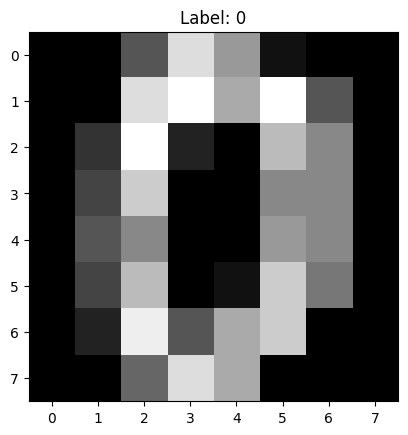

In [3]:
plt.imshow(digits.images[0],cmap='gray')
plt.title(f"Label: {y[0]}")
plt.show()

## **Step 4: Train-Test Split**

In [4]:
X_train, X_test, y_train , y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)

## **Step 5 : Feature Scaling**

In [5]:
from pandas.core.tools.datetimes import Scalar
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Step 6: One Hot Encoding**

In [6]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

Step 4,5 and 6 are the basic preprocessing steps

## **Step 7: Build ANN Model**

In [9]:
model = Sequential()

model.add(Dense(64,activation='relu', input_shape=(64,)))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax')) # softmax is activation function

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

## **Step 8: Compile Model**

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## **Step 9: Train Model**

In [11]:
history = model.fit(
    X_train,y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6210 - loss: 1.4919 - val_accuracy: 0.8403 - val_loss: 0.8466
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8855 - loss: 0.5224 - val_accuracy: 0.9236 - val_loss: 0.3990
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9358 - loss: 0.2634 - val_accuracy: 0.9236 - val_loss: 0.3028
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9621 - loss: 0.1670 - val_accuracy: 0.9375 - val_loss: 0.2550
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9714 - loss: 0.1183 - val_accuracy: 0.9306 - val_loss: 0.2369
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9822 - loss: 0.0853 - val_accuracy: 0.9375 - val_loss: 0.2313
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9892 - loss: 0.0631 - val_accuracy: 0.9444 - val_loss: 0.2375
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9930 - loss: 0.0484 - val_accuracy: 0.9514 - val_loss

## **Step 10: Evaluate Model**

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9833 - loss: 0.0937
Test Loss: 0.09367543458938599
Test Accuracy: 0.9833333492279053


## **Step 11: Predictions**

In [13]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred,axis = 1)
y_true = np.argmax(y_test,axis=1)

print("Predicted:",y_pred_classes[:10])
print("Actual :",y_true[:10])


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Predicted: [6 9 3 7 2 1 5 2 5 2]
Actual : [6 9 3 7 2 1 5 2 5 2]


## **Step 12: Visualize Prediction**

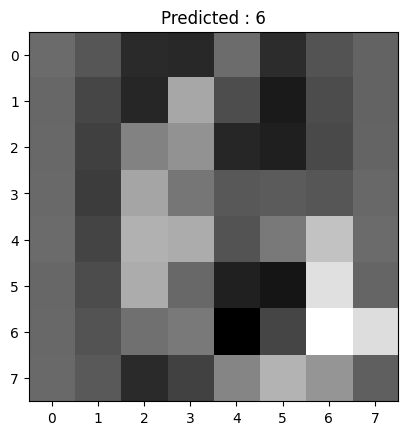

In [19]:
plt.imshow(X_test[0].reshape(8,8), cmap='gray')
plt.title(f"Predicted : {y_pred_classes[0]}")
plt.show()
